<h1>Project 1: Data Analysis Project<h1>

<h2> 1 Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [2]:
# %pip install git+https://github.com/alemartinello/dstapi
# %pip install fredapi

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dstapi import DstApi
import pandas as pd

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})


In [4]:
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')


Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [5]:
IFOR41.variable_levels('ULLIG',language='en') ##might not be necessary

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [6]:
params = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

ginidk = IFOR41.get_data(params=params)
ginidk.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [7]:
ginidk=ginidk.drop(columns=['ULLIG','KOMMUNEDK'])
ginidk = ginidk.rename(columns={'INDHOLD':'gini', 'TID': 'year'})
ginidk= ginidk.set_index('year').sort_index()

ginidk.head(5)

,gini
year,
1987,22.07
1988,22.06
1989,21.93
1990,22.16
1991,21.99


Text(0, 0.5, 'Gini')

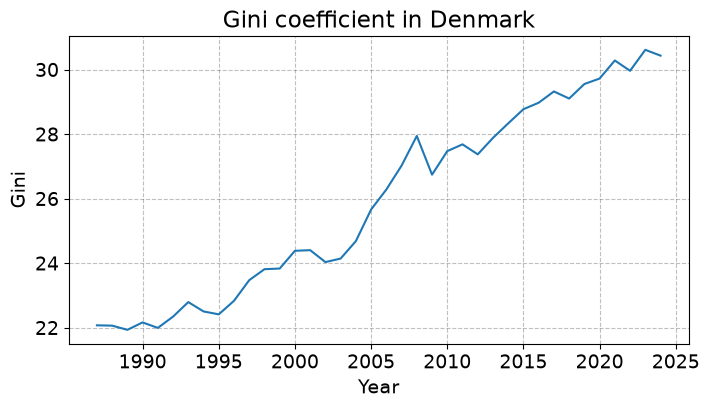

In [8]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot()
ax.plot(ginidk.index,ginidk['gini'].astype(float))
ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini')

In [9]:
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [10]:
params = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

df = IFOR32.get_data(params=params)
df.head(10)
df.tail(10)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
370,First decil,All Denmark,2001,62629
371,Second decil,All Denmark,2001,98552
372,Third decil,All Denmark,2001,114430
373,Fourth decil,All Denmark,2001,129885
374,Fifth decil,All Denmark,2001,144273
375,Sixth decil,All Denmark,2001,158392
376,Seventh decil,All Denmark,2001,173884
377,Eigth decil,All Denmark,2001,193021
378,Ninth decil,All Denmark,2001,221638
379,Tenth decil,All Denmark,2001,338942


In [11]:
df=df.drop(columns=['KOMMUNEDK'])
df = df.rename(columns={'INDHOLD':'income', 'TID': 'year'})
df= df.set_index('year').sort_index()

df.head(5)

,DECILGEN,income
year,,
1987,Third decil,68786
1987,Fourth decil,77577
1987,Fifth decil,85361
1987,Sixth decil,92777
1987,Seventh decil,100691


<Axes: title={'center': 'Top 10% income share in Denmark'}, xlabel='Year', ylabel='Share of total income'>

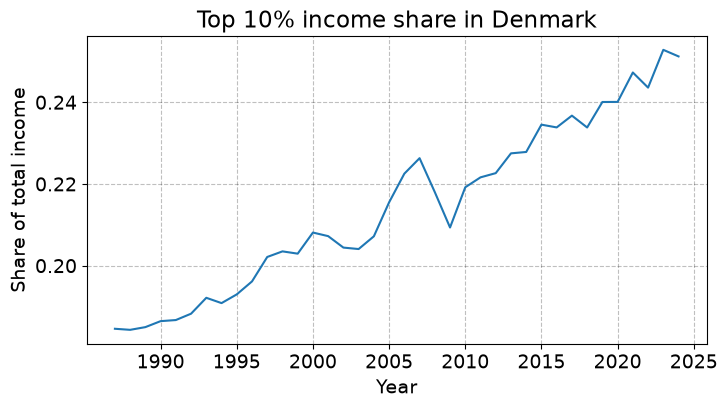

In [12]:
pivot = df.pivot_table(values='income', index=df.index, columns='DECILGEN', aggfunc='sum')
top10_share = pivot['Tenth decil'] / pivot.sum(axis=1)

top10_share.plot(title='Top 10% income share in Denmark', ylabel='Share of total income', xlabel='Year', figsize=(8,4))

#Describe how inequality in Denmark has developed since 1987. Do the two measures
tell the same story? 

Both graphs show gradually increasing inequality from 1987 to 2000, a slight dip from 2000 to ~2003 followed by a sharp spike that peaked immediately before the financial crisis and sharply fell during it, before continuing on its previous trend of gradually increasing from 2010-2024.


In [13]:
#Compute the correlation between them over time
np.corrcoef(ginidk['gini'].astype(float), top10_share)[0,1]

1



1

### 1.2 Prediction

In [14]:
import scipy
from scipy.optimize import minimize

In [ ]:
y= ginidk['gini'].astype(float).values
t = ginidk.index.astype(int).values - 1987
t = t.astype(float)
t[t == 0] = 1e-6  # undgå 0**k problemer

S1 = lambda beta: (sum(y-(beta + beta*t)))**2
S2= lambda beta: (sum(y-(beta + beta*t+beta*t**2)))**2

minproblin= scipy.optimize.minimize(S1, x0=0.00001, constraints=None)
minprobqua= scipy.optimize.minimize(S2, x0=0.00001, constraints=None)

# returner beta
beta1= minproblin.x[0]
beta2 = minprobqua.x[0]

print("beta1 = " + str(beta1))
print("beta2 = " + str(beta2))

beta1 = 1.3291497883265453
beta2 = 0.053772651928974624


In [ ]:
# Check answer!!!!!!
coeff_lin = np.polyfit(t,y,1)
a1_lin, a0_lin = coeff_lin
print("Hældning_lin: ", a1_lin)
print("Skæring_lin: ", a0_lin)

coeff_quad= np.polyfit(t,y,2)
a2_qua, a1_qua, a0_qua = coeff_quad
print(coeff_quad)
#?np.polyfit()

Hældning_lin:  0.2635496237887986
Skæring_lin:  21.04275300560328
[1.17769067e-03 2.19975069e-01 2.13042003e+01]


Text(2040.5, 153.95210247265436, '2040 (quadratic)')

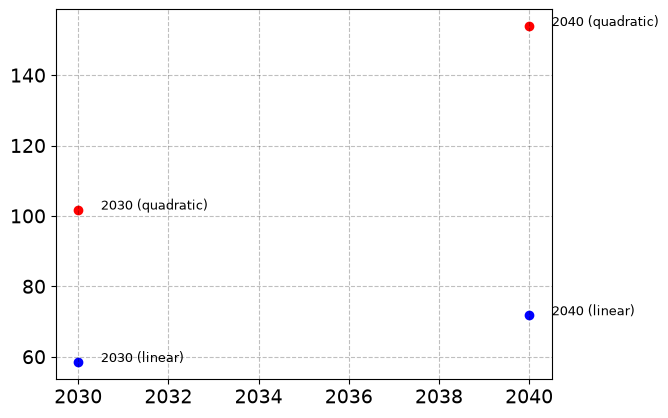

In [ ]:
#plot the Gini coefficient in 2030 and 2040
t2030=2030-1987
t2040=2040-1987

"""
To find y, I set y to the formula S1 and S2 because the difference between them should be 0 if the formula is correctly minimized.
"""
lin_gin2030 = beta1 + beta1*t2030
lin_gin2040 = beta1 + beta1*t2040
quad_gin2030= beta2 + beta2*t2030+beta2*t2030**2
quad_gin2040= beta2 + beta2*t2040+beta2*t2040**2

plt.scatter(2030, lin_gin2030, color='blue')
plt.text(2030 + 0.5, lin_gin2030 + 0.001, '2030 (linear)', fontsize=9)

plt.scatter(2040, lin_gin2040, color='blue')
plt.text(2040 + 0.5, lin_gin2040 + 0.001, '2040 (linear)', fontsize=9)

plt.scatter(2030, quad_gin2030, color='red')
plt.text(2030 + 0.5, quad_gin2030 + 0.001, '2030 (quadratic)', fontsize=9)

plt.scatter(2040, quad_gin2040, color='red')
plt.text(2040 + 0.5, quad_gin2040 + 0.001, '2040 (quadratic)', fontsize=9)

Explaining the graph:
...

### 1.3 Municipalities

### 1.4 Extension

<h2> 2 Simulating the income distribution

### 2.1 The model

### 2.2 Simulate the income distribution

### 2.3 Compute the Gini coefficient

### 2.4 What drives inequality?

### 2.5 Extension: more risk